In [14]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np  
import pandas as pd
import os

In [15]:
data = yf.download(["XOM", "PEP" , "CVX", "MSFT" ,"AAPL"] , start = "2020-01-01" , end = "2024-01-01" , auto_adjust = True)
print(data.shape)
print(data.head())

[*********************100%***********************]  5 of 5 completed

(1006, 25)
Price           Close                                                \
Ticker           AAPL        CVX        MSFT         PEP        XOM   
Date                                                                  
2020-01-02  72.333878  91.182571  151.829544  112.112404  52.947033   
2020-01-03  71.630638  90.867195  149.939056  111.955574  52.521366   
2020-01-06  72.201393  90.559319  150.326569  112.384789  52.924622   
2020-01-07  71.861847  89.402908  148.955933  110.618332  52.491501   
2020-01-08  73.017807  88.381660  151.328568  111.187904  51.699902   

Price            High                                                ...  \
Ticker           AAPL        CVX        MSFT         PEP        XOM  ...   
Date                                                                 ...   
2020-01-02  72.394086  91.332750  151.933525  113.276277  53.036643  ...   
2020-01-03  72.389257  92.151245  151.196270  112.913085  53.298023  ...   
2020-01-06  72.239927  91.362788  150.39

In [16]:
prices = data["Close"]
print(prices.shape)
print(prices.head())
print(prices.isna().sum())

(1006, 5)
Ticker           AAPL        CVX        MSFT         PEP        XOM
Date                                                               
2020-01-02  72.333878  91.182571  151.829544  112.112404  52.947033
2020-01-03  71.630638  90.867195  149.939056  111.955574  52.521366
2020-01-06  72.201393  90.559319  150.326569  112.384789  52.924622
2020-01-07  71.861847  89.402908  148.955933  110.618332  52.491501
2020-01-08  73.017807  88.381660  151.328568  111.187904  51.699902
Ticker
AAPL    0
CVX     0
MSFT    0
PEP     0
XOM     0
dtype: int64


In [17]:
print(prices.describe())
print(prices.min())

Ticker         AAPL          CVX         MSFT          PEP          XOM
count   1006.000000  1006.000000  1006.000000  1006.000000  1006.000000
mean     137.831005   107.216332   253.632410   139.117646    65.197250
std       33.327124    33.127886    54.692254    20.105933    26.291013
min       54.163700    41.190010   128.358337    86.368118    23.823561
25%      120.286205    78.246525   212.372940   120.016150    44.534123
50%      142.684906    98.956718   250.385040   143.183533    55.561817
75%      163.044838   139.321220   293.126930   155.097256    93.946020
max      195.892624   162.461304   375.406067   177.249725   109.624413
Ticker
AAPL     54.163700
CVX      41.190010
MSFT    128.358337
PEP      86.368118
XOM      23.823561
dtype: float64


In [18]:
TICKERS = [ "XOM", "CVX", "COP", "EOG", "SLB", "HAL",
    "JPM", "BAC", "WFC", "GS", "MS", "C", "AXP",
    "KO", "PEP", "PG", "CL", "KMB", "GIS",
    "V", "MA", "PYPL",
    "MSFT", "GOOGL", "META", "AAPL", "AMZN",
    "JNJ", "PFE", "MRK", "ABT", "UNH",
    "CAT", "DE", "HON", "MMM", "GE",
    "WMT", "TGT", "COST", "KR",]
raw = yf.download(TICKERS ,start = "2018-01-01" , end = "2024-01-01" , auto_adjust= True)
# auto_adjust=True: returns the original Adj Close as Close
#back_adjust=True: returns the original Close as Close
prices = raw["Close"]
print(prices.shape)

[*********************100%***********************]  41 of 41 completed


(1509, 41)


In [19]:
#drop the tickers with too many missing values
missing_pct = prices.isna().mean()
print(missing_pct.sort_values(ascending=False).head(3))
print("Total tickers with any NaN:",(missing_pct > 0).sum())


Ticker
AAPL    0.0
ABT     0.0
AMZN    0.0
dtype: float64
Total tickers with any NaN: 0


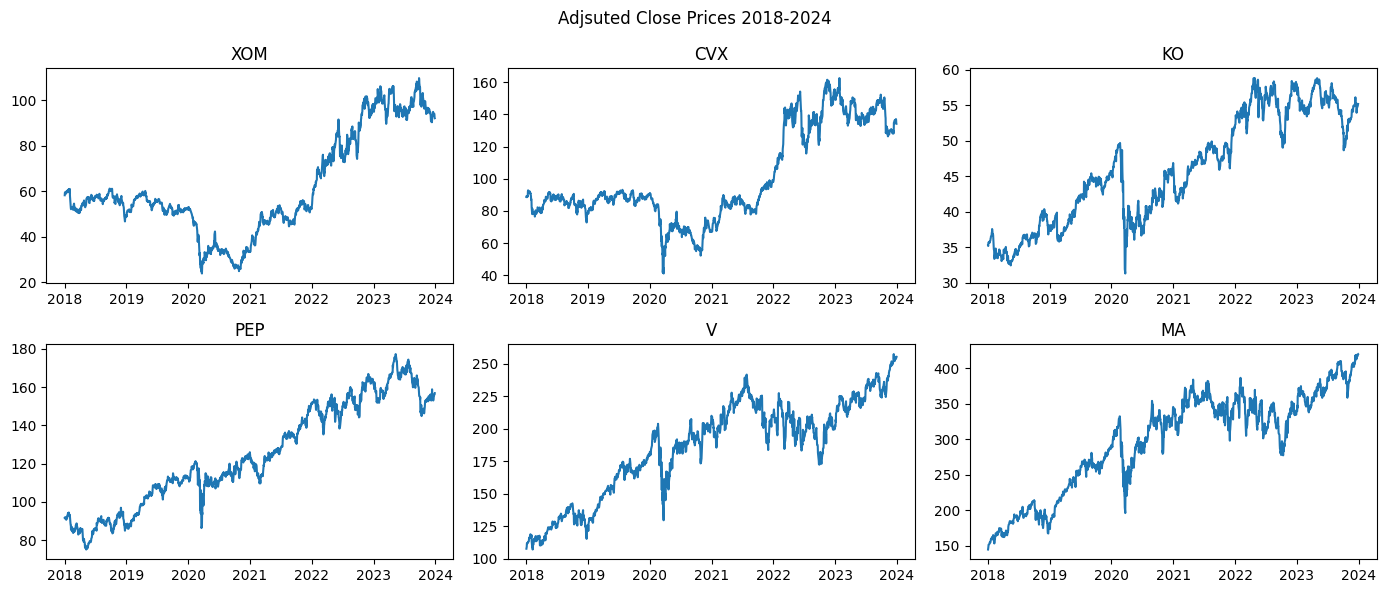

In [20]:
# plot price history 
tickers_to_plot = ["XOM","CVX", "KO" , "PEP" , "V" , "MA"]
fig,axes = plt.subplots(2,3,figsize=(14,6))
axes = axes.flatten()

for i , ticker in enumerate(tickers_to_plot):
    axes[i].plot(prices[ticker])
    axes[i].set_title(ticker)


plt.suptitle("Adjsuted Close Prices 2018-2024")
plt.tight_layout()
plt.savefig("../data/price_history.png",dpi = 120)
plt.show()


In [23]:
# save prices to parquet
os.makedirs("../data",exist_ok=True)
prices.to_parquet("../data/prices.parquet")

#reload and verify
verify = pd.read_parquet("../data/prices.parquet")
print(verify.shape)
print(verify.isna().sum().sum())

(1509, 41)
0


In [25]:
import sys
sys.path.append("../src")
from data_loader import load_prices

df = load_prices()
print(df.shape)

(1509, 41)
